# Tortuosity via LBM diffusion solver

This example computes the diffusional tortuosity of a PoreSpy-generated porous medium using the D3Q7 BGK lattice Boltzmann solver.

In [1]:
import porespy as ps
import matplotlib.pyplot as plt
import poromics

## Generate a porous medium image

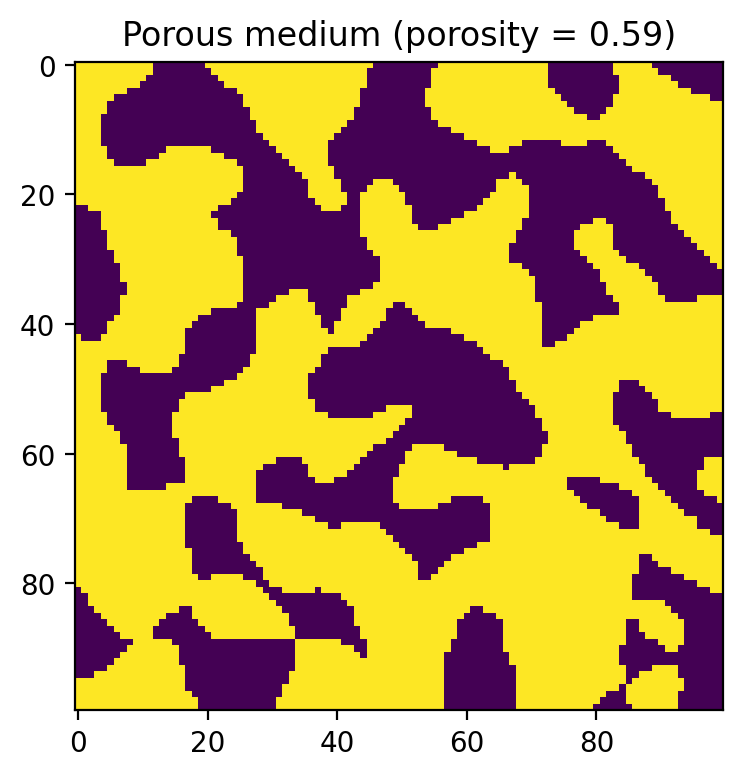

In [2]:
im = ps.generators.blobs(shape=[100, 100, 1], porosity=0.6, blobiness=0.5, seed=42)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im[:, :, 0], cmap="viridis", interpolation="nearest")
ax.set_title(f"Porous medium (porosity = {im.mean():.2f})")
plt.tight_layout()

## Compute tortuosity

The LBM solver accepts physical SI units. Here we use a diffusivity of $10^{-9}$ m²/s (typical for ions in water) and a voxel size of 1 µm.

In [3]:
result = poromics.tortuosity_lbm(im, axis=1, D=1e-9, voxel_size=1e-6)
print(result)
print(f"Tortuosity: {result.tau:.4f}")
print(f"Effective diffusivity (D_eff/D_0): {result.D_eff:.6f}")
print(f"Formation factor: {result.formation_factor:.4f}")

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.12.9


[I 03/08/26 11:48:47.018 19839838] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


Output()

[Taichi] Starting on arch=metal


TortuosityResult(tau=5.1417, D_eff=0.096290, axis=1)
Tortuosity: 5.1417
Effective diffusivity (D_eff/D_0): 0.096290
Formation factor: 10.3853


## Visualize the concentration field

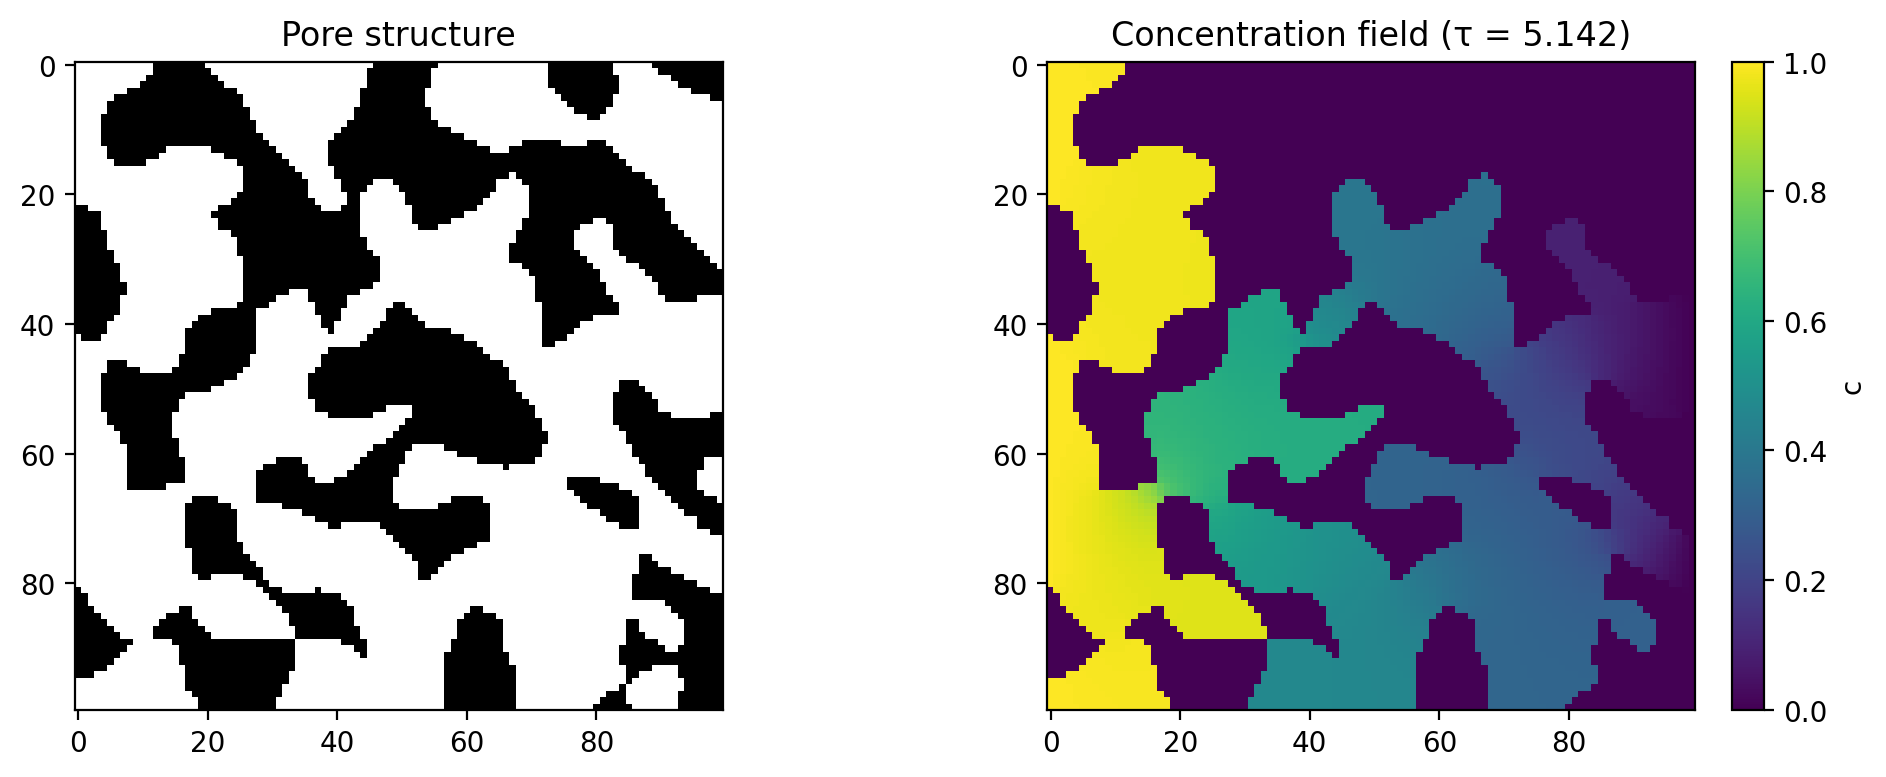

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(im[:, :, 0], cmap="gray", interpolation="nearest")
axes[0].set_title("Pore structure")

cax = axes[1].imshow(result.c[:, :, 0], cmap="viridis", interpolation="nearest")
axes[1].set_title(f"Concentration field (τ = {result.tau:.3f})")
fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04, label="c")

plt.tight_layout()

## Using the low-level solver

For more control, use `TransientDiffusion` directly. This lets you access intermediate state, step manually, or customize convergence criteria.

In [5]:
from poromics.simulation import TransientDiffusion

solver = TransientDiffusion(im, axis=1, D=1e-9, voxel_size=1e-6)
solver.run(n_steps=50_000, tol=1e-2)

print(f"Converged: {solver.converged}")
print(f"Iterations: {solver.n_iterations}")
print(f"Physical time step: {solver.dt:.2e} s")
print(f"Midplane flux: {solver.flux(axis=1):.6f}")

Converged: True
Iterations: 7001
Physical time step: 2.50e-04 s
Midplane flux: 0.000304
